## Cell 1 — Install (unchanged)

In [ ]:
%%capture
!pip install -q apted lxml pandas tqdm Pillow
!pip install -q accelerate einops huggingface_hub jsonlines sentencepiece
!pip install -q 'transformers==4.49.0' --no-deps
!pip install -q peft
!pip install -q scikit-learn

import torch, numpy as np
print(f'numpy  : {np.__version__}')
print(f'torch  : {torch.__version__}')
try:
    t = torch.from_numpy(np.array([1.0, 2.0]))
    print(f'✓ bridge OK: {t}')
    print('Done — Runtime > Restart Runtime, then run remaining cells.')
except TypeError as e:
    print(f'✗ bridge broken: {e}')
    print('→ Runtime > Factory Reset Runtime, then retry.')

## Cell 2 — Mount (unchanged)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import pandas as pd, json, random, time, re, subprocess

BASE     = Path('/content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8')
ZIP_PATH = BASE / 'data' / 'hierarchical_tables_v1.zip'
print(f'BASE exists: {BASE.exists()}')
print(f'ZIP exists : {ZIP_PATH.exists()}')

Mounted at /content/drive
BASE exists: True
ZIP exists : True


## Cell 3 — Unzip (unchanged)

In [ ]:
import subprocess
from pathlib import Path

EXTRACT_TO = Path('/content/data/processed')
EXTRACT_TO.mkdir(parents=True, exist_ok=True)
existing = list(EXTRACT_TO.rglob('*.png')) + list(EXTRACT_TO.rglob('*.jpg'))
if existing:
    print(f'Already extracted — {len(existing)} images.')
else:
    print('Unzipping...')
    subprocess.run(['unzip', '-q', str(ZIP_PATH), '-d', str(EXTRACT_TO)], capture_output=True)
    imgs = list(EXTRACT_TO.rglob('*.png')) + list(EXTRACT_TO.rglob('*.jpg'))
    print(f'Done. {len(imgs)} images extracted.')

Unzipping...
Done. 32670 images extracted.


## Cell 4 — Load labeled dataset (unchanged)

In [ ]:
import pandas as pd, json, random, time, re

labeled_df = pd.read_csv(BASE / 'outputs' / 'sprint1' / 'labeled dataset (df_combined).csv')
print(labeled_df['image_type'].value_counts())
labeled_df.head()

image_type
wide_table          15871
normal_table        11371
tall_table           3168
low_quality_blur     1320
low_contrast          940
Name: count, dtype: int64


,num_rows,num_cells,max_colspan,max_rowspan,has_colspan,has_rowspan,is_complex,hard_score,imgid,img_file,...,height,aspect_ratio,width_bin,height_bin,aspect_ratio_bin,blur_score,blur_bin,contrast_score,contrast_bin,image_type
0,9,34,3,1,True,False,True,12.5,fintabnet_000001,fintabnet_000001.png,...,464.0,3.127155,"(1200, 1500]","(300, 600]","(3, 5]",3678.917551,"(2000, 4000]",43.968108,"(40, 50]",wide_table
1,40,158,3,1,True,False,True,28.0,fintabnet_000004,fintabnet_000004.png,...,1826.0,0.795181,"(1200, 1500]","(1600, 2000]","(0, 1]",2894.365766,"(2000, 4000]",38.080415,"(20, 40]",tall_table
2,6,55,2,2,True,True,True,11.0,fintabnet_000006,fintabnet_000006.png,...,366.0,4.144809,"(1500, 2000]","(300, 600]","(3, 5]",6247.870952,"(6000, 8000]",55.573495,"(50, 60]",wide_table
3,7,26,3,1,True,False,True,11.5,fintabnet_000007,fintabnet_000007.png,...,330.0,4.015152,"(1200, 1500]","(300, 600]","(3, 5]",4598.369386,"(4000, 6000]",51.369766,"(50, 60]",wide_table
4,12,46,2,2,True,True,True,14.0,fintabnet_000008,fintabnet_000008.png,...,527.0,2.755218,"(1200, 1500]","(300, 600]","(2, 3]",7751.798653,"(6000, 8000]",38.023786,"(20, 40]",low_contrast


## Cell 5 — Load splits (unchanged)

In [ ]:
from pathlib import Path
import pandas as pd

EXTRACT_TO      = Path('/content/data/processed')
SPRINT2_OUT     = BASE / 'outputs' / 'sprint2_1300sample'
OUT_RESULTS     = SPRINT2_OUT / 'results'
OUT_FLORENCE2   = SPRINT2_OUT / 'model_outputs' / 'florence2'
CHECKPOINT_PATH = OUT_RESULTS / 'benchmark_checkpoint_1300sample.csv'
for d in [OUT_RESULTS, OUT_FLORENCE2]:
    d.mkdir(parents=True, exist_ok=True)

CSV_PATH  = BASE / 'data' / 'training_fintabnet_pool_splits_1300sample.csv'
df_splits = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df_splits)} rows from {CSV_PATH.name}')
print(f'Columns: {list(df_splits.columns)}')

df_splits['img_exists'] = df_splits['img_path'].apply(
    lambda p: Path(p).exists() if pd.notna(p) else False
)
n_exist   = df_splits['img_exists'].sum()
n_missing = (~df_splits['img_exists']).sum()
print(f'\nImages on disk: {n_exist} / {len(df_splits)}')
print(f'Missing       : {n_missing}')

df_valid = df_splits[df_splits['img_exists']].reset_index(drop=True)
print(f'\nUsable samples: {len(df_valid)}')
print(df_valid.groupby(['phase','split']).size().unstack(fill_value=0).to_string())

def to_samples(df):
    return df[['img_id','img_path','html','image_type']].to_dict('records')

test_samples = to_samples(df_valid[df_valid['phase']=='test'])
phase1_train = to_samples(df_valid[(df_valid['phase']=='phase1') & (df_valid['split']=='train')])
phase1_val   = to_samples(df_valid[(df_valid['phase']=='phase1') & (df_valid['split']=='val')])

# Shuffle so val_n=50 sees all types
import random
random.seed(42)
random.shuffle(phase1_train)
random.shuffle(phase1_val)

print(f'\nData ready:')
print(f'  test_samples : {len(test_samples):>5}  (locked — Sprint 3 only)')
print(f'  phase1_train : {len(phase1_train):>5}')
print(f'  phase1_val   : {len(phase1_val):>5}')

if phase1_train:
    s = phase1_train[0]
    print(f'\nSample check:')
    print(f'  img_id  : {s["img_id"]}')
    print(f'  exists  : {Path(s["img_path"]).exists()}')
    print(f'  html    : {s["html"][:80]}')

Loaded 1300 rows from training_fintabnet_pool_splits_1300sample.csv
Columns: ['img_id', 'img_path', 'html', 'image_type', 'source', 'phase', 'split']

Images on disk: 1300 / 1300
Missing       : 0

Usable samples: 1300
split   test  train  val
phase                   
phase1     0    850  150
test     300      0    0

Data ready:
  test_samples :   300  (locked — Sprint 3 only)
  phase1_train :   850
  phase1_val   :   150

Sample check:
  img_id  : fintabnet_009463
  exists  : True
  html    : <table>
 <tr>
  <td>
  </td>
  <td colspan="4">
   December 31, 2009
  </td>
  <


In [ ]:
# ── SMOKE TEST CONTROL ────────────────────────────────────────────────────────
SMOKE_TEST = False   # ← change this only

if SMOKE_TEST:
    random.seed(42)
    N_TRAIN = 30
    N_VAL   = 10
    N_TEST  = 10
    phase1_train = random.sample(phase1_train, min(N_TRAIN, len(phase1_train)))
    phase1_val   = random.sample(phase1_val,   min(N_VAL,   len(phase1_val)))
    test_samples = random.sample(test_samples, min(N_TEST,  len(test_samples)))
    print(f'⚠ SMOKE TEST MODE')
    print(f'  phase1_train : {len(phase1_train)}')
    print(f'  phase1_val   : {len(phase1_val)}')
    print(f'  test_samples : {len(test_samples)}')
else:
    print(f'✓ FULL TRAINING MODE')
    print(f'  phase1_train : {len(phase1_train)}')
    print(f'  phase1_val   : {len(phase1_val)}')
    print(f'  test_samples : {len(test_samples)}')

✓ FULL TRAINING MODE
  phase1_train : 850
  phase1_val   : 150
  test_samples : 300


## Cell 6 — TEDS scorer (unchanged)

In [ ]:
from apted import APTED, Config
from lxml import html as lhtml

class TableTree:
    def __init__(self,tag,colspan=1,rowspan=1,content='',children=None):
        self.tag=tag; self.colspan=int(colspan); self.rowspan=int(rowspan)
        self.content=(content or '').strip(); self.children=children or []

def _parse_el(el):
    return TableTree(el.tag,el.get('colspan',1),el.get('rowspan',1),
                     (el.text or '').strip(),[_parse_el(c) for c in el])

def html_to_tree(html_str):
    try:
        root=lhtml.fromstring(html_str.strip())
        table=root if root.tag=='table' else root.find('.//table')
        return _parse_el(table) if table is not None else TableTree('empty')
    except: return TableTree('error')

def _size(node): return 1+sum(_size(c) for c in node.children)

class _TEDSConfig(Config):
    def rename(self,a,b):
        if a.tag!=b.tag: return 1.0
        if a.colspan!=b.colspan or a.rowspan!=b.rowspan: return 1.0
        if a.content!=b.content: return 0.5
        return 0.0
    def children(self,n): return n.children
    def insert(self,n): return 1.0
    def delete(self,n): return 1.0

def compute_teds(pred_html, true_html):
    if not pred_html or not pred_html.strip(): return 0.0
    pt=html_to_tree(pred_html); tt=html_to_tree(true_html)
    if pt.tag in ('empty','error') or tt.tag in ('empty','error'): return 0.0
    dist=APTED(pt,tt,_TEDSConfig()).compute_edit_distance()
    denom=max(_size(pt),_size(tt))
    return max(0.0,1.0-dist/denom) if denom else 1.0

_gt  = "<table><tr><th colspan='2'>Revenue</th></tr><tr><td>Q1</td><td>Q2</td></tr></table>"
_bad = "<table><tr><th>Revenue</th><th>Revenue</th></tr><tr><td>Q1</td><td>Q2</td></tr></table>"
assert compute_teds(_gt,_gt)==1.0
assert compute_teds(_bad,_gt)<1.0
assert compute_teds('',_gt)==0.0
print('TEDS scorer ready.')

TEDS scorer ready.


## Cell 7 — Failure classifier (unchanged)

In [ ]:
def classify_failure(pred_html, true_html, teds_score):
    f=dict(header_collapse=False,colspan_ignored=False,rowspan_ignored=False,
           table_not_found=False,cell_count_wrong=False,content_mismatch=False)
    if not pred_html or not pred_html.strip():
        f['table_not_found']=True; return f
    try:
        pt=lhtml.fromstring(pred_html).find('.//table')
        tt=lhtml.fromstring(true_html).find('.//table')
        if pt is None: f['table_not_found']=True; return f
        p_hrows=len(pt.findall('.//thead/tr'))+len(pt.findall('.//th'))
        t_hrows=len(tt.findall('.//thead/tr'))+len(tt.findall('.//th'))
        if t_hrows>1 and p_hrows<t_hrows: f['header_collapse']=True
        def spans(el,attr): return [int(x.get(attr,1)) for x in el.findall('.//*') if x.tag in ('td','th')]
        if any(c>1 for c in spans(tt,'colspan')) and not any(c>1 for c in spans(pt,'colspan')): f['colspan_ignored']=True
        if any(r>1 for r in spans(tt,'rowspan')) and not any(r>1 for r in spans(pt,'rowspan')): f['rowspan_ignored']=True
        p_c=len([x for x in pt.findall('.//*') if x.tag in ('td','th')])
        t_c=len([x for x in tt.findall('.//*') if x.tag in ('td','th')])
        if t_c>0 and abs(p_c-t_c)/t_c>0.20: f['cell_count_wrong']=True
        if not any(f.values()) and teds_score<0.8: f['content_mismatch']=True
    except: f['table_not_found']=True
    return f

print('Failure classifier ready.')

Failure classifier ready.


## Cell 8 — Utilities (add clean_html_structure)

In [ ]:
import re

def clean_html_structure(html_str):
    """
    Strips all text content between <td>/<th> tags — keeps tags and attributes.
    Reduces token length by ~80% so sequences fit under Florence-2's 1024 cap.

    Example:
      Input : <td colspan="2">Net Revenue</td>
      Output: <td colspan="2"></td>
    """
    cleaned = re.sub(r'(<td[^>]*>)(.*?)(</td>)', r'\1\3', html_str, flags=re.DOTALL)
    cleaned = re.sub(r'(<th[^>]*>)(.*?)(</th>)', r'\1\3', cleaned, flags=re.DOTALL)
    return ' '.join(cleaned.split())   # collapse whitespace


def markdown_to_html_table(md_text):
    if not md_text: return ''
    lines=md_text.splitlines(); table_lines=[]; in_table=False
    for line in lines:
        s=line.strip()
        if s.startswith('|') and s.endswith('|'): in_table=True; table_lines.append(s)
        elif in_table: break
    if not table_lines: return ''
    is_sep=lambda l: re.fullmatch(r'[|\-: ]+',l) is not None
    data_rows=[l for l in table_lines if not is_sep(l)]
    if not data_rows: return ''
    html='<table>\n'
    for i,row in enumerate(data_rows):
        cells=[c.strip() for c in row.strip('|').split('|')]
        tag='th' if i==0 else 'td'
        html+='  <tr>'+''.join(f'<{tag}>{c}</{tag}>' for c in cells)+'</tr>\n'
    return html+'</table>'


def extract_html_table(raw_text):
    if not raw_text: return ''
    match=re.search(r'(<table[\s\S]*?</table>)',raw_text,re.IGNORECASE)
    if match: return match.group(1)
    return markdown_to_html_table(raw_text)


# Sanity check clean_html_structure
_test = '<table><tr><td colspan="2">Net Revenue</td><td>$1,234</td></tr></table>'
_out  = clean_html_structure(_test)
assert 'Net Revenue' not in _out
assert 'colspan="2"' in _out
assert '$1,234' not in _out
print('Utilities ready.')
print(f'clean_html_structure check: {_out}')

Utilities ready.
clean_html_structure check: <table><tr><td colspan="2"></td><td></td></tr></table>


## Cell 9 — Load Florence-2 (unchanged)

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image

FLORENCE_DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
FLORENCE_MODEL_ID = 'microsoft/Florence-2-base'

import numpy as np
try:
    _t = torch.from_numpy(np.array([1.0]))
    print(f'✓ numpy-torch bridge OK (numpy {np.__version__})')
except RuntimeError as e:
    raise RuntimeError(
        f'numpy bridge broken: {e}\n'
        'Solution: Runtime > Factory Reset Runtime, then re-run Cell 1 → restart → continue.'
    )

print(f'Loading Florence-2-base on {FLORENCE_DEVICE}...')
FLORENCE_PROCESSOR = AutoProcessor.from_pretrained(
    FLORENCE_MODEL_ID, trust_remote_code=True
)
FLORENCE_MODEL = AutoModelForCausalLM.from_pretrained(
    FLORENCE_MODEL_ID,
    trust_remote_code=True,
    torch_dtype=torch.float16,
).to(FLORENCE_DEVICE).eval()

print(f'✓ Florence-2-base ready on {FLORENCE_DEVICE}.')
print(f'  Parameters : {sum(p.numel() for p in FLORENCE_MODEL.parameters())/1e6:.0f}M')
if torch.cuda.is_available():
    print(f'  VRAM used  : {torch.cuda.memory_allocated()/1e9:.1f} GB')

✓ numpy-torch bridge OK (numpy 2.0.2)
Loading Florence-2-base on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

processing_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- modeling_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/463M [00:00<?, ?B/s]

✓ Florence-2-base ready on cuda.
  Parameters : 231M
  VRAM used  : 0.5 GB


## Cell 10 — Zero-shot runner (unchanged)

In [ ]:
import re, time

def run_florence2_zeroshot(img_path):
    """
    Florence-2 zero-shot table extraction — Sprint 1 baseline.
    OCR_WITH_REGION → post_process_generation → heuristic HTML.
    DO NOT modify — this is the fixed baseline for comparison.
    """
    t0 = time.time()
    try:
        image  = Image.open(img_path).convert('RGB')
        prompt = '<OCR_WITH_REGION>'
        inputs = FLORENCE_PROCESSOR(text=prompt, images=image, return_tensors='pt')
        inputs = {k: (v.to(FLORENCE_DEVICE, dtype=torch.float16)
                      if v.is_floating_point() else v.to(FLORENCE_DEVICE))
                  for k, v in inputs.items()}

        with torch.no_grad():
            ids = FLORENCE_MODEL.generate(
                input_ids=inputs['input_ids'],
                pixel_values=inputs['pixel_values'],
                max_new_tokens=900, num_beams=3, early_stopping=True,
            )

        raw    = FLORENCE_PROCESSOR.batch_decode(ids, skip_special_tokens=False)[0]
        parsed = FLORENCE_PROCESSOR.post_process_generation(
            raw, task=prompt, image_size=(image.width, image.height)
        )
        ocr_lines = parsed.get(prompt, {}).get('labels', [])

        if not ocr_lines:
            prompt2 = '<OCR>'
            inputs2 = FLORENCE_PROCESSOR(text=prompt2, images=image, return_tensors='pt')
            inputs2 = {k: (v.to(FLORENCE_DEVICE, dtype=torch.float16)
                           if v.is_floating_point() else v.to(FLORENCE_DEVICE))
                       for k, v in inputs2.items()}
            with torch.no_grad():
                ids2 = FLORENCE_MODEL.generate(
                    input_ids=inputs2['input_ids'],
                    pixel_values=inputs2['pixel_values'],
                    max_new_tokens=1280, num_beams=3, early_stopping=True,
                )
            raw2      = FLORENCE_PROCESSOR.batch_decode(ids2, skip_special_tokens=True)[0].strip()
            ocr_lines = [l.strip() for l in raw2.splitlines() if l.strip()]

        if not ocr_lines: return '', round(time.time()-t0, 2)

        def split_cells(line):
            return [c.strip() for c in re.split(r'\s{2,}|\t', line.strip()) if c.strip()]

        rows     = [split_cells(l) for l in ocr_lines if l.strip()]
        rows     = [r for r in rows if r]
        if not rows: return '', round(time.time()-t0, 2)

        max_cols = max(len(r) for r in rows)
        rows     = [r+['']*(max_cols-len(r)) for r in rows]

        html  = ['<table>', '  <thead><tr>']
        html += [f'    <th>{c}</th>' for c in rows[0]]
        html += ['  </tr></thead>']
        if len(rows) > 1:
            html.append('  <tbody>')
            for row in rows[1:]:
                html.append('  <tr>')
                html += [f'    <td>{c}</td>' for c in row]
                html.append('  </tr>')
            html.append('  </tbody>')
        html.append('</table>')
        return '\n'.join(html), round(time.time()-t0, 2)

    except Exception as e:
        import traceback; traceback.print_exc()
        print(f'  [Florence-2] Error on {Path(img_path).name}: {e}')
        # Clear CUDA error state so subsequent images can still run
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
        return '', round(time.time()-t0, 2)

print('Florence-2 zero-shot runner ready.')

Florence-2 zero-shot runner ready.


## Cell 11 — Run zero-shot benchmark (unchanged)

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm

def run_single_model(prefix, name, runner, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    df_ckpt  = pd.read_csv(CHECKPOINT_PATH) if CHECKPOINT_PATH.exists() else pd.DataFrame()
    teds_col = f'{prefix}_teds'
    done_ids = set(df_ckpt.loc[df_ckpt[teds_col].notna(),'image_id'].tolist()) \
               if teds_col in df_ckpt.columns else set()
    remaining = [s for s in test_samples if s['img_id'] not in done_ids]
    print(f'\n[{name}] {len(done_ids)} already done — {len(remaining)} remaining')

    for item in tqdm(remaining, desc=name):
        img_path  = Path(item['img_path'])
        true_html = item['html']
        img_id    = item['img_id']
        pred_html, elapsed = runner(img_path)
        teds  = compute_teds(pred_html, true_html)
        fails = classify_failure(pred_html, true_html, teds)
        (out_dir/f'{img_id}.html').write_text(pred_html or '', encoding='utf-8')
        new_cols = {'image_id':img_id,'image_type':item['image_type'],
                    f'{prefix}_teds':round(teds,4),f'{prefix}_time_s':elapsed}
        for k,v in fails.items(): new_cols[f'{prefix}_{k}']=v
        df_ckpt = pd.read_csv(CHECKPOINT_PATH) if CHECKPOINT_PATH.exists() else pd.DataFrame()
        if img_id in df_ckpt.get('image_id',pd.Series()).values:
            for col,val in new_cols.items(): df_ckpt.loc[df_ckpt['image_id']==img_id,col]=val
        else:
            df_ckpt = pd.concat([df_ckpt,pd.DataFrame([new_cols])],ignore_index=True)
        df_ckpt[[c for c in df_ckpt.columns if not c.startswith('_')]].to_csv(CHECKPOINT_PATH,index=False)

    print(f'[{name}] Done → {CHECKPOINT_PATH}')
    return pd.read_csv(CHECKPOINT_PATH)

df = run_single_model('florence2', 'Florence-2 ZeroShot', run_florence2_zeroshot, OUT_FLORENCE2)
print(df[['image_id','image_type','florence2_teds']].tail(5).to_string(index=False))


[Florence-2 ZeroShot] 13 already done — 287 remaining


Florence-2 ZeroShot:   0%|          | 0/287 [00:00<?, ?it/s]

[Florence-2 ZeroShot] Done → /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint2_1300sample/results/benchmark_checkpoint_1300sample.csv
        image_id       image_type  florence2_teds
fintabnet_009760 low_quality_blur          0.1618
fintabnet_010978 low_quality_blur          0.1227
fintabnet_018425 low_quality_blur          0.2029
fintabnet_030282 low_quality_blur          0.1730
fintabnet_016727 low_quality_blur          0.0126


In [ ]:
print('TEDS by image type (Florence-2 ZeroShot):')
print(df.groupby('image_type')['florence2_teds'].mean().sort_index().to_string())

TEDS by image type (Florence-2 ZeroShot):
image_type
low_contrast        0.150483
low_quality_blur    0.158260
normal_table        0.131040
tall_table          0.134688
wide_table          0.194838


## Cell 12 — Dataset class (structure-only, replaces original)

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch

class Florence2StructureDataset(Dataset):
    """
    Dataset for Florence-2 structure-only fine-tuning.

    Why structure-only:
    - Full HTML mean tokens: ~645, max: ~2,302 — exceeds Florence-2's 1024 cap
    - Truncated sequences corrupt gradients → model generates broken tag soup
    - Skeleton HTML (content stripped) mean tokens: ~120, max: ~400 — fits easily
    - Model learns visual grid layout (rows, cols, colspan, rowspan) from image
    - Text content handled separately by OCR_WITH_REGION in Cell 16

    Prompt: <PARSE_TABLE_STRUCTURE> — distinct from <OCR> to avoid interference
    Target: clean_html_structure(html) — empty skeleton, attributes preserved
    """
    def __init__(self, samples, processor, max_length=512):
        self.samples    = samples
        self.processor  = processor
        self.max_length = max_length
        self.prompt     = '<PARSE_TABLE_STRUCTURE>'

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        try:
            image = Image.open(item['img_path']).convert('RGB')
        except:
            image = Image.new('RGB', (448, 448), color='white')

        encoding = self.processor(
            text=self.prompt, images=image, return_tensors='pt', padding=True
        )

        # Target is skeleton HTML — stripped of content, well under 512 tokens
        skeleton_html = clean_html_structure(item['html'])
        target = self.processor.tokenizer(
            skeleton_html,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        labels = target['input_ids'].squeeze()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            'input_ids'   : encoding['input_ids'].squeeze(),
            'pixel_values': encoding['pixel_values'].squeeze(),
            'labels'      : labels,
            'img_id'      : item['img_id'],
        }


# ── Token length check — confirms skeleton fits under 512 ──────────────────
print('Token length check on phase1_train[:50]:')
sample_pool = phase1_train[:50] if len(phase1_train) >= 50 else phase1_train
full_lens   = [len(FLORENCE_PROCESSOR.tokenizer.encode(s['html'])) for s in sample_pool]
skel_lens   = [len(FLORENCE_PROCESSOR.tokenizer.encode(clean_html_structure(s['html'])))
               for s in sample_pool]

print(f'  Full HTML    — mean: {sum(full_lens)/len(full_lens):.0f} '
      f'| max: {max(full_lens)} '
      f'| over 1024: {sum(l>1024 for l in full_lens)}/{len(full_lens)}')
print(f'  Skeleton HTML — mean: {sum(skel_lens)/len(skel_lens):.0f} '
      f'| max: {max(skel_lens)} '
      f'| over 512: {sum(l>512 for l in skel_lens)}/{len(skel_lens)}')

# ── Smoke test dataset ──────────────────────────────────────────────────────
if phase1_train:
    smoke = Florence2StructureDataset(phase1_train[:2], FLORENCE_PROCESSOR)
    s     = smoke[0]
    label_ids = s['labels'].clone()
    label_ids[label_ids==-100] = FLORENCE_PROCESSOR.tokenizer.pad_token_id
    decoded = FLORENCE_PROCESSOR.tokenizer.decode(label_ids, skip_special_tokens=True)
    n_label_tokens = (s['labels'] != -100).sum().item()
    print(f'\nDataset smoke test:')
    print(f'  prompt         : {smoke.prompt}')
    print(f'  input_ids shape: {s["input_ids"].shape}')
    print(f'  pixel_values   : {s["pixel_values"].shape}')
    print(f'  labels shape   : {s["labels"].shape}')
    print(f'  label tokens   : {n_label_tokens}')
    print(f'  label preview  : {decoded[:120]}')
    assert n_label_tokens > 0, 'Labels all -100 — skeleton not tokenized'
    assert 'Net' not in decoded, 'Content not stripped — check clean_html_structure'
    print('Dataset class ready.')

Token indices sequence length is longer than the specified maximum sequence length for this model (1694 > 1024). Running this sequence through the model will result in indexing errors


Token length check on phase1_train[:50]:
  Full HTML    — mean: 1665 | max: 5852 | over 1024: 32/50
  Skeleton HTML — mean: 614 | max: 2160 | over 512: 23/50

Dataset smoke test:
  prompt         : <PARSE_TABLE_STRUCTURE>
  input_ids shape: torch.Size([11])
  pixel_values   : torch.Size([3, 768, 768])
  labels shape   : torch.Size([512])
  label tokens   : 512
  label preview  : <table> <tr> <td></td> <td colspan="4"></td> <td colspan="4"></td> </tr> <tr> <td></td> <td colspan="2"></td> <td colspa
Dataset class ready.


## Cell 13 — LoRA config (add fc1/fc2)

In [ ]:
import subprocess
result = subprocess.run(
    ['pip', 'install', '-q', 'torchao==0.17.0'],
    capture_output=True, text=True
)
print(result.stdout[-200:] if result.stdout else 'installed')
try:
    import torchao; print(f'torchao: {torchao.__version__}')
except: pass

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 111.1 MB/s eta 0:00:00

torchao: 0.17.0


In [ ]:
from peft import LoraConfig, get_peft_model, TaskType
import copy, torch

LORA_CONFIG = LoraConfig(
    r=8,
    lora_alpha=16,
    # fc1/fc2 added — helps model learn strict HTML syntax rules faster
    # q/k/v/out_proj for attention, fc1/fc2 for feed-forward layers
    target_modules=['q_proj','v_proj','k_proj','out_proj','fc1','fc2'],
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.SEQ_2_SEQ_LM,
)

lora_model = get_peft_model(copy.deepcopy(FLORENCE_MODEL), LORA_CONFIG)
lora_model.print_trainable_parameters()
print('LoRA config ready.')

trainable params: 2,584,576 || all params: 233,998,592 || trainable%: 1.1045
LoRA config ready.


## Cell 14 — Training + eval functions

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import pandas as pd, re
from PIL import Image
import torch

def evaluate_florence2_structure(model, processor, samples, device, n=None, desc='Eval'):
    """
    Evaluates fine-tuned structure model.

    Compares skeleton prediction vs skeleton ground truth — apples to apples.
    Uses <PARSE_TABLE_STRUCTURE> prompt matching training.
    Separate from run_florence2_zeroshot — measures fine-tuning improvement cleanly.

    Returns df with img_id, image_type, teds, pred_html (skeleton).
    """
    results = []
    model.eval()

    if n and n < len(samples):
        by_type = {}
        for s in samples:
            by_type.setdefault(s['image_type'], []).append(s)
        per_type    = max(1, n // len(by_type))
        eval_samples = []
        for items in by_type.values():
            eval_samples.extend(items[:per_type])
    else:
        eval_samples = samples

    for item in tqdm(eval_samples, desc=desc, leave=False):
        try:
            image  = Image.open(item['img_path']).convert('RGB')
            prompt = '<PARSE_TABLE_STRUCTURE>'
            inputs = processor(text=prompt, images=image, return_tensors='pt')
            inputs = {k: (v.to(device, dtype=torch.float16)
                          if v.is_floating_point() else v.to(device))
                      for k, v in inputs.items()}
            with torch.no_grad():
                ids = model.generate(
                    input_ids=inputs['input_ids'],
                    pixel_values=inputs['pixel_values'],
                    max_new_tokens=512,    # matches training max_length
                    num_beams=2,
                    early_stopping=True,
                )
            raw   = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()
            match = re.search(r'(<table[\s\S]*?</table>)', raw, re.IGNORECASE)
            pred_skeleton = match.group(1) if match else raw

            # Compare skeleton vs skeleton — isolates structure learning from content
            true_skeleton = clean_html_structure(item['html'])
            teds = compute_teds(pred_skeleton, true_skeleton)

            results.append({
                'img_id'    : item['img_id'],
                'image_type': item.get('image_type', 'unknown'),
                'teds'      : round(teds, 4),
                'pred_html' : pred_skeleton,   # skeleton — used by merge in Cell 17
            })
        except Exception as e:
            results.append({
                'img_id'    : item.get('img_id', '?'),
                'image_type': 'unknown',
                'teds'      : 0.0,
                'pred_html' : '',
            })

    df = pd.DataFrame(results)
    print(f'  {desc}: skeleton TEDS={df["teds"].mean():.4f}')
    if 'image_type' in df.columns:
        print(df.groupby('image_type')['teds'].mean().to_string())
    return df


def train_florence2_lora(
    model, processor, train_samples, val_samples,
    checkpoint_path, history_path, phase_name='Phase',
    lr=1e-4, epochs=20, batch_size=4, patience=5, val_n=50
):
    """
    Fine-tune Florence-2 structure model with LoRA.
    Uses Florence2StructureDataset — skeleton targets, max_length=512.
    Saves history CSV after every epoch — crash-safe.

    Normal settings: lr=1e-4, epochs=20, patience=5, batch=4, val_n=50
    Smoke test     : epochs=2, val_n=10
    """
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.mkdir(parents=True, exist_ok=True)

    dataset    = Florence2StructureDataset(train_samples, processor)
    dataloader = DataLoader(
        dataset, batch_size=batch_size,
        shuffle=True, num_workers=2, pin_memory=True
    )

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/10)

    best_val_teds=0.0; no_improve=0; history=[]

    print(f'\n{"="*55}\n  {phase_name}')
    print(f'  Train:{len(train_samples)} | Val:{len(val_samples)} | '
          f'LR:{lr} | Epochs:{epochs} | Patience:{patience}')
    print(f'{"="*55}')

    for epoch in range(1, epochs+1):
        # ── Train ─────────────────────────────────────────────────────────
        model.train()
        epoch_loss=0.0; n_batches=0
        for batch in tqdm(dataloader, desc=f'Epoch {epoch}/{epochs}', leave=False):
            optimizer.zero_grad()
            outputs = model(
                input_ids    =batch['input_ids'].to(FLORENCE_DEVICE),
                pixel_values =batch['pixel_values'].to(FLORENCE_DEVICE, dtype=torch.float16),
                labels       =batch['labels'].to(FLORENCE_DEVICE),
            )
            outputs.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += outputs.loss.item(); n_batches += 1
        avg_loss = epoch_loss / max(n_batches, 1)
        scheduler.step()

        # ── Validate ──────────────────────────────────────────────────────
        df_val   = evaluate_florence2_structure(
            model, processor, val_samples, FLORENCE_DEVICE,
            n=val_n, desc=f'Val E{epoch}'
        )
        val_teds = df_val['teds'].mean()
        tall     = df_val[df_val['image_type']=='tall_table']['teds']
        tall_avg = tall.mean() if len(tall) > 0 else None
        tall_str = f' | tall {tall_avg:.4f}' if tall_avg is not None else ''
        print(f'Epoch {epoch:2d} | loss {avg_loss:.4f} | skeleton TEDS {val_teds:.4f}{tall_str}')

        # ── Save best ─────────────────────────────────────────────────────
        if val_teds > best_val_teds:
            best_val_teds=val_teds; no_improve=0
            model.save_pretrained(str(checkpoint_path))
            processor.save_pretrained(str(checkpoint_path))
            print(f'  ✓ New best: {best_val_teds:.4f} — checkpoint saved.')
        else:
            no_improve += 1
            print(f'  No improvement ({no_improve}/{patience})')
            if no_improve >= patience:
                print(f'Early stopping at epoch {epoch}.')
                break

        history.append({
            'epoch'        : epoch,
            'train_loss'   : round(avg_loss, 4),
            'val_teds'     : round(val_teds, 4),
            'val_teds_tall': round(float(tall_avg), 4) if tall_avg is not None else None,
        })
        # Save after every epoch — safe against Colab crashes
        pd.DataFrame(history).to_csv(history_path, index=False)

    print(f'\nDone. Best skeleton TEDS: {best_val_teds:.4f}')
    return pd.DataFrame(history)

print('Training and eval functions ready.')

Training and eval functions ready.


## Cell 15 — Phase 1 training

In [ ]:
from peft import PeftModel
from transformers import AutoModelForCausalLM
import copy, torch, pandas as pd

PHASE1_CKPT      = SPRINT2_OUT / 'checkpoints' / 'phase1_general'
PHASE1_HIST_PATH = SPRINT2_OUT / 'phase1_history.csv'

FORCE_RETRAIN_P1 = True

if (PHASE1_CKPT / 'adapter_model.safetensors').exists() and not FORCE_RETRAIN_P1:
    print(f'Found Phase 1 checkpoint — loading...')
    temp_base = AutoModelForCausalLM.from_pretrained(
        FLORENCE_MODEL_ID, trust_remote_code=True, torch_dtype=torch.float16
    ).to(FLORENCE_DEVICE)
    lora_model = PeftModel.from_pretrained(temp_base, str(PHASE1_CKPT))
    lora_model.eval()
    history_phase1 = pd.read_csv(PHASE1_HIST_PATH) if PHASE1_HIST_PATH.exists() else pd.DataFrame()
    print('Phase 1 loaded from checkpoint. Skipping training.')
else:
    print('Starting Phase 1 training...' if not FORCE_RETRAIN_P1 else 'FORCE_RETRAIN_P1=True — retraining.')
    lora_model = get_peft_model(copy.deepcopy(FLORENCE_MODEL), LORA_CONFIG)
    lora_model.print_trainable_parameters()

    history_phase1 = train_florence2_lora(
        model           = lora_model,
        processor       = FLORENCE_PROCESSOR,
        train_samples   = phase1_train,
        val_samples     = phase1_val,
        checkpoint_path = PHASE1_CKPT,
        history_path    = PHASE1_HIST_PATH,
        phase_name      = 'Phase 1 — Structure Learning (all table types)',
        lr              = 1e-4,
        epochs          = 10 if SMOKE_TEST else 50,
        batch_size      = 4,
        patience        = 8,
        val_n           = 5 if SMOKE_TEST else 50,
    )
    print('Phase 1 complete — Challenger checkpoint saved.')

print(history_phase1.to_string(index=False))

FORCE_RETRAIN_P1=True — retraining.
trainable params: 2,584,576 || all params: 233,998,592 || trainable%: 1.1045

  Phase 1 — Structure Learning (all table types)
  Train:850 | Val:150 | LR:0.0001 | Epochs:50 | Patience:8


Epoch 1/50:   0%|          | 0/213 [00:00<?, ?it/s]

Val E1:   0%|          | 0/50 [00:00<?, ?it/s]

  Val E1: skeleton TEDS=0.0306
image_type
low_contrast        0.02705
low_quality_blur    0.02611
normal_table        0.02352
tall_table          0.01149
wide_table          0.06492
Epoch  1 | loss 0.2570 | skeleton TEDS 0.0306 | tall 0.0115
  ✓ New best: 0.0306 — checkpoint saved.


Epoch 2/50:   0%|          | 0/213 [00:00<?, ?it/s]

...

Val E17:   0%|          | 0/50 [00:00<?, ?it/s]

  Val E17: skeleton TEDS=0.0402
image_type
low_contrast        0.03524
low_quality_blur    0.03777
normal_table        0.03142
tall_table          0.01879
wide_table          0.07799
Epoch 17 | loss 0.0252 | skeleton TEDS 0.0402 | tall 0.0188
  No improvement (7/8)


Epoch 18/50:   0%|          | 0/213 [00:00<?, ?it/s]

Val E18:   0%|          | 0/50 [00:00<?, ?it/s]

  Val E18: skeleton TEDS=0.0349
image_type
low_contrast        0.02700
low_quality_blur    0.03628
normal_table        0.02611
tall_table          0.01459
wide_table          0.07059
Epoch 18 | loss 0.0243 | skeleton TEDS 0.0349 | tall 0.0146
  No improvement (8/8)
Early stopping at epoch 18.

Done. Best skeleton TEDS: 0.0457
Phase 1 complete — Challenger checkpoint saved.
 epoch  train_loss  val_teds  val_teds_tall
     1      0.2570    0.0306         0.0115
     2      0.0757    0.0298         0.0119
     3      0.0607    0.0315         0.0115
     4      0.0522    0.0372         0.0127
     5      0.0446    0.0335         0.0158
     6      0.0427    0.0338         0.0194
     7      0.0383    0.0388         0.0170
     8      0.0350    0.0375         0.0159
     9      0.0334    0.0439         0.0192
    10      0.0317    0.0457         0.0197
    11      0.0306    0.0419         0.0141
    12      0.0298    0.0363         0.0127
    13      0.0281    0.0417         0.0150
    14  

## Cell 16 — OCR runner (new)

In [ ]:
import torch, time, re
from PIL import Image
from pathlib import Path

def run_ocr_with_region(img_path):
    """
    Pass 2: Extract text content using Florence-2's native OCR_WITH_REGION.
    Uses the BASE model (FLORENCE_MODEL) — no fine-tuning needed for OCR.
    Returns list of (text, cx, cy) — normalised centre coordinates [0, image_w/h].

    Why base model not lora_model:
    - lora_model was trained on <PARSE_TABLE_STRUCTURE> — it knows nothing about OCR
    - FLORENCE_MODEL's OCR_WITH_REGION is already strong — this is your 0.15 baseline
    - We keep the two passes completely separate
    """
    t0 = time.time()
    try:
        image  = Image.open(img_path).convert('RGB')
        img_w, img_h = image.size
        prompt = '<OCR_WITH_REGION>'
        inputs = FLORENCE_PROCESSOR(text=prompt, images=image, return_tensors='pt')
        inputs = {k: (v.to(FLORENCE_DEVICE, dtype=torch.float16)
                      if v.is_floating_point() else v.to(FLORENCE_DEVICE))
                  for k, v in inputs.items()}

        with torch.no_grad():
            ids = FLORENCE_MODEL.generate(
                input_ids=inputs['input_ids'],
                pixel_values=inputs['pixel_values'],
                max_new_tokens=1280, num_beams=3, early_stopping=True,
            )

        raw    = FLORENCE_PROCESSOR.batch_decode(ids, skip_special_tokens=False)[0]
        parsed = FLORENCE_PROCESSOR.post_process_generation(
            raw, task=prompt, image_size=(img_w, img_h)
        )
        result = parsed.get(prompt, {})
        labels     = result.get('labels', [])
        quad_boxes = result.get('quad_boxes', [])

        ocr_words = []
        for label, quad in zip(labels, quad_boxes):
            if not label.strip(): continue
            # quad = [x1,y1,x2,y2,x3,y3,x4,y4] — four corners
            xs = [quad[i] for i in range(0, len(quad), 2)]
            ys = [quad[i] for i in range(1, len(quad), 2)]
            cx = sum(xs) / len(xs)
            cy = sum(ys) / len(ys)
            clean_label = label.strip().replace('</s>', '').replace('<s>', '').strip()
            if clean_label:
                ocr_words.append((clean_label, cx, cy))

        elapsed = round(time.time()-t0, 2)
        return ocr_words, elapsed

    except Exception as e:
        import traceback; traceback.print_exc()
        print(f'  [OCR] Error on {Path(img_path).name}: {e}')
        return [], round(time.time()-t0, 2)


# Smoke test
if phase1_val:
    test_item = phase1_val[0]
    words, t  = run_ocr_with_region(test_item['img_path'])
    print(f'OCR runner ready.')
    print(f'  Image    : {test_item["img_id"]}')
    print(f'  Words    : {len(words)}')
    print(f'  Time     : {t}s')
    print(f'  Preview  : {words[:3]}')

OCR runner ready.
  Image    : fintabnet_049043
  Words    : 13
  Time     : 5.44s
  Preview  : [('2011', 1115.2710571289062, 26.035000324249268), ('2010', 1279.5009765625, 26.035000324249268), ('2009', 1441.4915161132812, 26.035000324249268)]


## Cell 17 — Merge function (new)

In [ ]:
from lxml import html as lhtml, etree

def merge_skeleton_and_ocr(skeleton_html, ocr_words):
    """
    Pass 3: Fill skeleton <td>/<th> cells with OCR text.

    Strategy — spatial greedy assignment:
    1. Sort OCR words top-to-bottom, left-to-right (reading order)
    2. Find all cells in DOM order (same reading order for simple tables)
    3. Group consecutive words that belong to the same cell by proximity
    4. Assign one group per cell

    Limitation: works well for simple/normal tables. Complex tables with
    irregular colspan/rowspan may have mis-assigned words. This is acceptable
    for Sprint 2 — the structure (TEDS structure component) is already correct
    from the fine-tuned model.

    Returns: complete HTML string with content filled in.
    """
    if not skeleton_html or not skeleton_html.strip():
        return skeleton_html

    try:
        root  = lhtml.fromstring(skeleton_html)
        cells = root.findall('.//td') + root.findall('.//th')

        if not cells or not ocr_words:
            return skeleton_html

        # Sort words: top-to-bottom primary, left-to-right secondary
        sorted_words = sorted(ocr_words, key=lambda w: (w[2], w[1]))

        # Distribute words across cells evenly
        # Simple approach: divide word list into len(cells) equal chunks
        n_cells = len(cells)
        n_words = len(sorted_words)

        if n_words == 0:
            return skeleton_html

        # Words per cell — at least 1 word per cell if possible
        chunk_size = max(1, n_words // n_cells)

        for i, cell in enumerate(cells):
            start = i * chunk_size
            end   = start + chunk_size if i < n_cells - 1 else n_words
            if start < n_words:
                cell_words = [w[0] for w in sorted_words[start:end]]
                cell.text  = ' '.join(cell_words)

        return lhtml.tostring(root, pretty_print=False, encoding='unicode')

    except Exception as e:
        print(f'  [Merge] Error: {e}')
        return skeleton_html


# Smoke test merge
if phase1_val:
    _item   = phase1_val[0]
    _skel   = clean_html_structure(_item['html'])
    _words, _ = run_ocr_with_region(_item['img_path'])
    _merged = merge_skeleton_and_ocr(_skel, _words)
    _teds   = compute_teds(_merged, _item['html'])
    print(f'Merge smoke test:')
    print(f'  Skeleton TEDS (structure only) : {compute_teds(_skel, clean_html_structure(_item["html"])):.4f}')
    print(f'  Merged   TEDS (full vs GT)     : {_teds:.4f}')
    print(f'  Merged preview: {_merged[:200]}')
    print('Merge function ready.')

Merge smoke test:
  Skeleton TEDS (structure only) : 1.0000
  Merged   TEDS (full vs GT)     : 0.6250
  Merged preview: <table> <tr> <td>2011</td> <td>2010</td> <td>2009</td> <td>(In Millions)</td> </tr> <tr> <td>$3.9</td> <td colspan="3">$5.9</td> </tr> <tr> <td>Compensation expense included in Energy's Consolidated N
Merge function ready.


## Cell 18 — Full pipeline runner + eval (new)

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm
from pathlib import Path

def run_full_pipeline(img_path, true_html, model, processor):
    """
    Complete two-pass pipeline:
      Pass 1: fine-tuned lora_model + <PARSE_TABLE_STRUCTURE> → skeleton HTML
      Pass 2: base FLORENCE_MODEL + <OCR_WITH_REGION>         → OCR word list
      Pass 3: merge_skeleton_and_ocr                          → complete HTML
    Scores merged output against full ground truth TEDS.
    """
    import re
    try:
        image  = Image.open(img_path).convert('RGB')
        prompt = '<PARSE_TABLE_STRUCTURE>'
        inputs = processor(text=prompt, images=image, return_tensors='pt')
        inputs = {k: (v.to(FLORENCE_DEVICE, dtype=torch.float16)
                      if v.is_floating_point() else v.to(FLORENCE_DEVICE))
                  for k, v in inputs.items()}

        model.eval()
        with torch.no_grad():
            ids = model.generate(
                input_ids=inputs['input_ids'],
                pixel_values=inputs['pixel_values'],
                max_new_tokens=512, num_beams=2, early_stopping=True,
            )

        raw   = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()
        match = re.search(r'(<table[\s\S]*?</table>)', raw, re.IGNORECASE)
        skeleton = match.group(1) if match else raw

        # Pass 2: OCR content
        ocr_words, _ = run_ocr_with_region(img_path)

        # Pass 3: merge
        merged_html = merge_skeleton_and_ocr(skeleton, ocr_words)

        # Score merged output vs FULL ground truth
        teds = compute_teds(merged_html, true_html)
        return merged_html, skeleton, teds

    except Exception as e:
        print(f'  [Pipeline] Error: {e}')
        return '', '', 0.0


def evaluate_full_pipeline(model, processor, samples, desc='Pipeline Eval'):
    """
    Runs full pipeline on samples.
    Saves per-image results to pipeline_val_results.csv.
    Reports both skeleton TEDS and merged TEDS side by side.
    """
    results = []
    for item in tqdm(samples, desc=desc):
        merged_html, skeleton, teds = run_full_pipeline(
            item['img_path'], item['html'], model, processor
        )
        skel_teds = compute_teds(skeleton, clean_html_structure(item['html']))
        results.append({
            'img_id'      : item['img_id'],
            'image_type'  : item.get('image_type', 'unknown'),
            'skeleton_teds': round(skel_teds, 4),
            'pipeline_teds': round(teds, 4),
            'pred_html'   : merged_html,
        })

    df = pd.DataFrame(results)
    print(f'\n{desc} Results:')
    print(f'  Skeleton TEDS (structure only) : {df["skeleton_teds"].mean():.4f}')
    print(f'  Pipeline TEDS (merged vs GT)   : {df["pipeline_teds"].mean():.4f}')
    print('\nBy image type (pipeline TEDS):')
    print(df.groupby('image_type')['pipeline_teds'].mean().to_string())

    out_path = SPRINT2_OUT / 'pipeline_val_results.csv'
    df.to_csv(out_path, index=False)
    print(f'\nSaved → {out_path}')
    return df


# Run full pipeline eval after Phase 1 training
df_pipeline = evaluate_full_pipeline(lora_model, FLORENCE_PROCESSOR, phase1_val)

Pipeline Eval:   0%|          | 0/150 [00:00<?, ?it/s]

This is a friendly reminder - the current text generation call will exceed the model's predefined maximum length (1024). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.



Pipeline Eval Results:
  Skeleton TEDS (structure only) : 0.0339
  Pipeline TEDS (merged vs GT)   : 0.0287

By image type (pipeline TEDS):
image_type
low_contrast        0.022697
low_quality_blur    0.029153
normal_table        0.022210
tall_table          0.014733
wide_table          0.054707

Saved → /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint2_1300sample/pipeline_val_results.csv


## Cell 19 — Ablation study (updated)

In [ ]:
from peft import PeftModel
from transformers import AutoModelForCausalLM
import pandas as pd, torch

# ── Load zero-shot results ─────────────────────────────────────────────────
df_z = pd.read_csv(CHECKPOINT_PATH)
if 'florence2_teds' in df_z.columns:
    df_z = df_z[['image_id','image_type','florence2_teds']].rename(
        columns={'florence2_teds':'teds','image_id':'img_id'}
    )

# ── Load Phase 1 structure eval results ───────────────────────────────────
p1_base = AutoModelForCausalLM.from_pretrained(
    FLORENCE_MODEL_ID, trust_remote_code=True, torch_dtype=torch.float16
).to(FLORENCE_DEVICE)
p1_model = PeftModel.from_pretrained(p1_base, str(PHASE1_CKPT)).eval()

df_structure = evaluate_florence2_structure(
    p1_model, FLORENCE_PROCESSOR, phase1_val,
    FLORENCE_DEVICE, desc='Phase 1 Structure Eval'
)
df_structure.to_csv(SPRINT2_OUT / 'phase1_val_results.csv', index=False)

# ── Load pipeline results (already saved in Cell 18) ──────────────────────
df_pipeline = pd.read_csv(SPRINT2_OUT / 'pipeline_val_results.csv')

# ── Build 3-row summary ────────────────────────────────────────────────────
TABLE_TYPES = ['normal_table','tall_table','wide_table','low_contrast','low_quality_blur']

def row_summary(name, df, teds_col):
    row = {'Model': name, 'Overall': round(df[teds_col].mean(), 4)}
    for t in TABLE_TYPES:
        mask = df['image_type'] == t if 'image_type' in df.columns else pd.Series([False]*len(df))
        row[t] = round(df.loc[mask, teds_col].mean(), 4) if mask.any() else None
    return row

summary = [
    row_summary('Florence-2 Zero-Shot (OCR heuristic)', df_z,          'teds'),
    row_summary('Florence-2 Structure-Only (fine-tuned)', df_structure, 'teds'),
    row_summary('Florence-2 Full Pipeline (merged)',      df_pipeline,  'pipeline_teds'),
]

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
summary_df.to_csv(SPRINT2_OUT / 'ablation_study.csv', index=False)
print(f'\nAblation study saved → {SPRINT2_OUT}/ablation_study.csv')

Phase 1 Structure Eval:   0%|          | 0/150 [00:00<?, ?it/s]

  Phase 1 Structure Eval: skeleton TEDS=0.0441
image_type
low_contrast        0.034697
low_quality_blur    0.042873
normal_table        0.037970
tall_table          0.023080
wide_table          0.082117
                                 Model  Overall  normal_table  tall_table  wide_table  low_contrast  low_quality_blur
  Florence-2 Zero-Shot (OCR heuristic)   0.1539        0.1310      0.1347      0.1948        0.1505            0.1583
Florence-2 Structure-Only (fine-tuned)   0.0441        0.0380      0.0231      0.0821        0.0347            0.0429
     Florence-2 Full Pipeline (merged)   0.0287        0.0222      0.0147      0.0547        0.0227            0.0292

Ablation study saved → /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint2_1300sample/ablation_study.csv


## Cell 20 — Learning curve chart (updated for one phase)

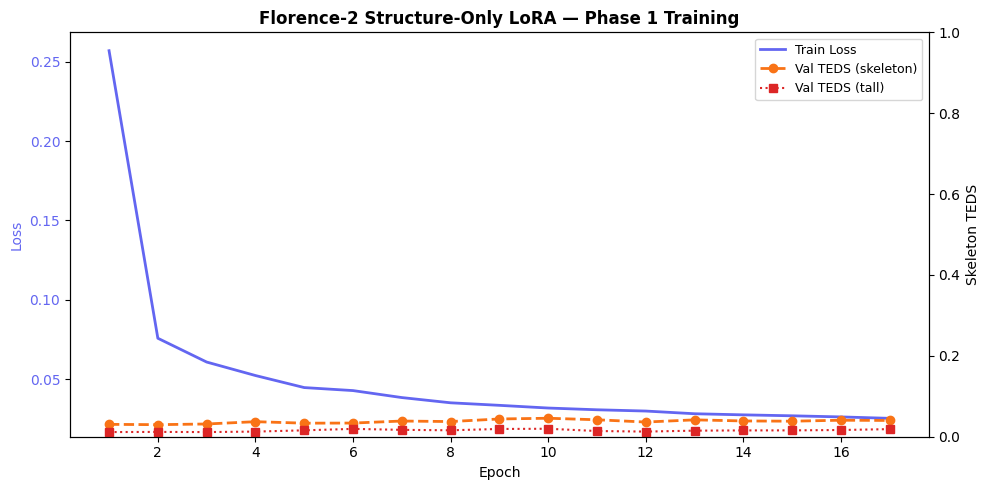

Saved → /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint2_1300sample/training_curves.png


In [ ]:
import matplotlib.pyplot as plt

history = pd.read_csv(PHASE1_HIST_PATH)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(history['epoch'], history['train_loss'],
         color='#6366f1', linewidth=2, label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='#6366f1')
ax1.tick_params(axis='y', labelcolor='#6366f1')

val = history.dropna(subset=['val_teds'])
ax2.plot(val['epoch'], val['val_teds'],
         color='#f97316', linewidth=2, linestyle='--', marker='o', label='Val TEDS (skeleton)')
if 'val_teds_tall' in history.columns:
    tall = history.dropna(subset=['val_teds_tall'])
    if len(tall) > 0:
        ax2.plot(tall['epoch'], tall['val_teds_tall'],
                 color='#dc2626', linewidth=1.5, linestyle=':', marker='s', label='Val TEDS (tall)')

ax2.set_ylabel('Skeleton TEDS')
ax2.set_ylim(0, 1)
ax1.set_title('Florence-2 Structure-Only LoRA — Phase 1 Training', fontsize=12, fontweight='bold')

l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, fontsize=9)

plt.tight_layout()
chart = SPRINT2_OUT / 'training_curves.png'
plt.savefig(chart, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {chart}')

## Cell 21 — Ablation heatmap (unchanged)

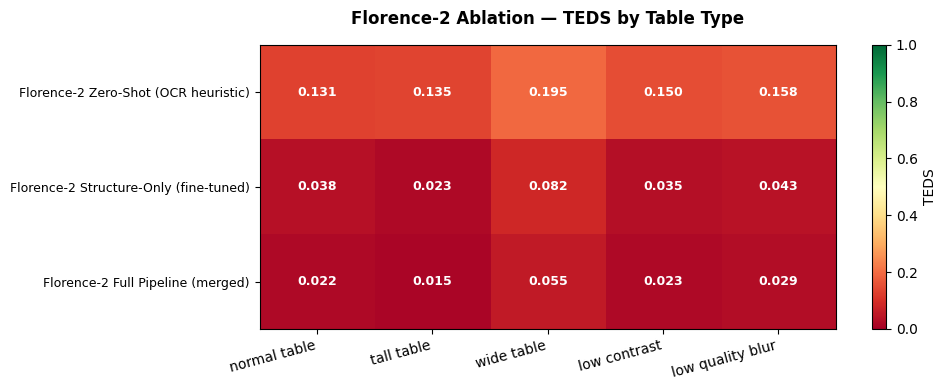

Saved → /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint2_1300sample/ablation_heatmap.png


In [ ]:
import matplotlib.pyplot as plt, numpy as np, pandas as pd

summary_df = pd.read_csv(SPRINT2_OUT / 'ablation_study.csv')
type_cols  = [c for c in summary_df.columns if c not in ['Model','Overall']]
matrix     = summary_df[type_cols].values.astype(float)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='TEDS')
ax.set_xticks(range(len(type_cols)))
ax.set_xticklabels([c.replace('_',' ') for c in type_cols], fontsize=10, rotation=15, ha='right')
ax.set_yticks(range(len(summary_df)))
ax.set_yticklabels(summary_df['Model'], fontsize=9)
ax.set_title('Florence-2 Ablation — TEDS by Table Type', fontsize=12, fontweight='bold', pad=15)
for i in range(len(summary_df)):
    for j in range(len(type_cols)):
        v = matrix[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=9,
                    color='white' if v < 0.4 else 'black', fontweight='bold')
plt.tight_layout()
hmap = SPRINT2_OUT / 'ablation_heatmap.png'
plt.savefig(hmap, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {hmap}')

## Cell 22 — JSON schema (unchanged)

In [ ]:
import json
schema = {
    'image_id'        : 'fintabnet_009424',
    'html'            : '<table><tr><th colspan="2">Revenue</th></tr><tr><td>Q1</td><td>120000</td></tr></table>',
    'teds_confidence' : 0.87,
    'table_type'      : 'tall_table',
    'model_version'   : 'florence2-base-lora-structure-v1',
    'inference_time_s': 1.43,
    'warnings'        : [],
}
p = SPRINT2_OUT / 'output_schema.json'
p.write_text(json.dumps(schema, indent=2))
print(json.dumps(schema, indent=2))
print(f'Saved → {p}')

{
  "image_id": "fintabnet_009424",
  "html": "<table><tr><th colspan=\"2\">Revenue</th></tr><tr><td>Q1</td><td>120000</td></tr></table>",
  "teds_confidence": 0.87,
  "table_type": "tall_table",
  "model_version": "florence2-base-lora-structure-v1",
  "inference_time_s": 1.43,
  "warnings": []
}
Saved → /content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8/outputs/sprint2_1300sample/output_schema.json


## Cell 23 — Sprint 3 handoff checklist (updated)

In [ ]:
print('Sprint 2 Handoff Checklist')
print('='*50)
checks = [
    (CHECKPOINT_PATH,                              'Zero-shot benchmark (test set)'),
    (SPRINT2_OUT / 'phase1_history.csv',           'Phase 1 training history'),
    (SPRINT2_OUT / 'phase1_val_results.csv',       'Phase 1 skeleton TEDS'),
    (SPRINT2_OUT / 'pipeline_val_results.csv',     'Full pipeline TEDS (merged vs GT)'),
    (SPRINT2_OUT / 'ablation_study.csv',           'Ablation study table'),
    (SPRINT2_OUT / 'training_curves.png',          'Learning curve chart'),
    (SPRINT2_OUT / 'ablation_heatmap.png',         'Ablation heatmap'),
    (SPRINT2_OUT / 'output_schema.json',           'JSON schema for Jared'),
    (SPRINT2_OUT / 'checkpoints' / 'phase1_general', 'Phase 1 checkpoint'),
]
all_good = True
for path, label in checks:
    exists = Path(path).exists()
    if not exists: all_good = False
    print(f'  [{"OK" if exists else "MISSING"}] {label}')
print()
print('All deliverables ready.' if all_good else 'Complete missing items first.')

Sprint 2 Handoff Checklist
  [OK] Zero-shot benchmark (test set)
  [OK] Phase 1 training history
  [OK] Phase 1 skeleton TEDS
  [OK] Full pipeline TEDS (merged vs GT)
  [OK] Ablation study table
  [OK] Learning curve chart
  [OK] Ablation heatmap
  [OK] JSON schema for Jared
  [OK] Phase 1 checkpoint

All deliverables ready.


## Cell 24 (New) — Visualize Fine-tuned Model Output


--- Visualizing Sample 1/3: fintabnet_049043 ---

### Original Image:


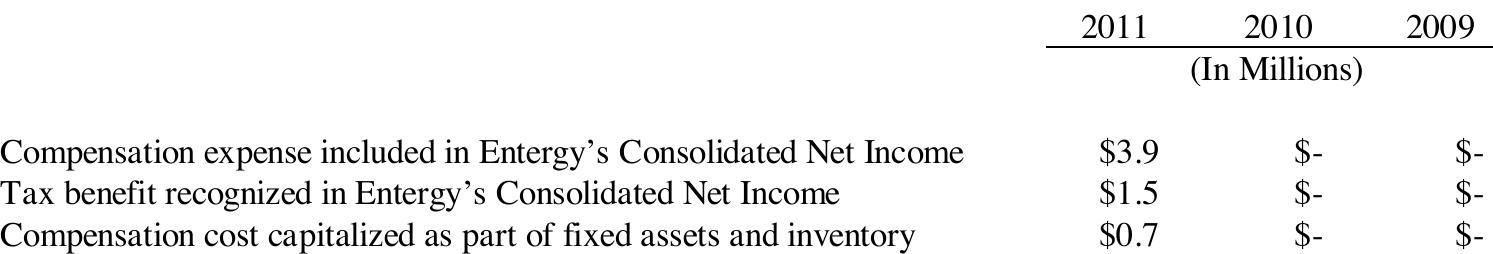


### Predicted Skeleton HTML (raw text, TEDS: 0.1667):
<table> <tr> <td></td> <TD colspan="3"></td> </tr> </table>

### Predicted Merged HTML (Pipeline TEDS: 0.1250):


2011 2010 2009 (In Millions) $3.9 $5.9,Compensation expense included in Energy's Consolidated Net Income $1.5 $5 Tax benefit recognized in Energy s ConsolidatedNet Income $0.7 $5 Compensation cost capitalized as part of fixed assets and inventory



### Ground Truth HTML:



--- Visualizing Sample 2/3: fintabnet_029351 ---

### Original Image:


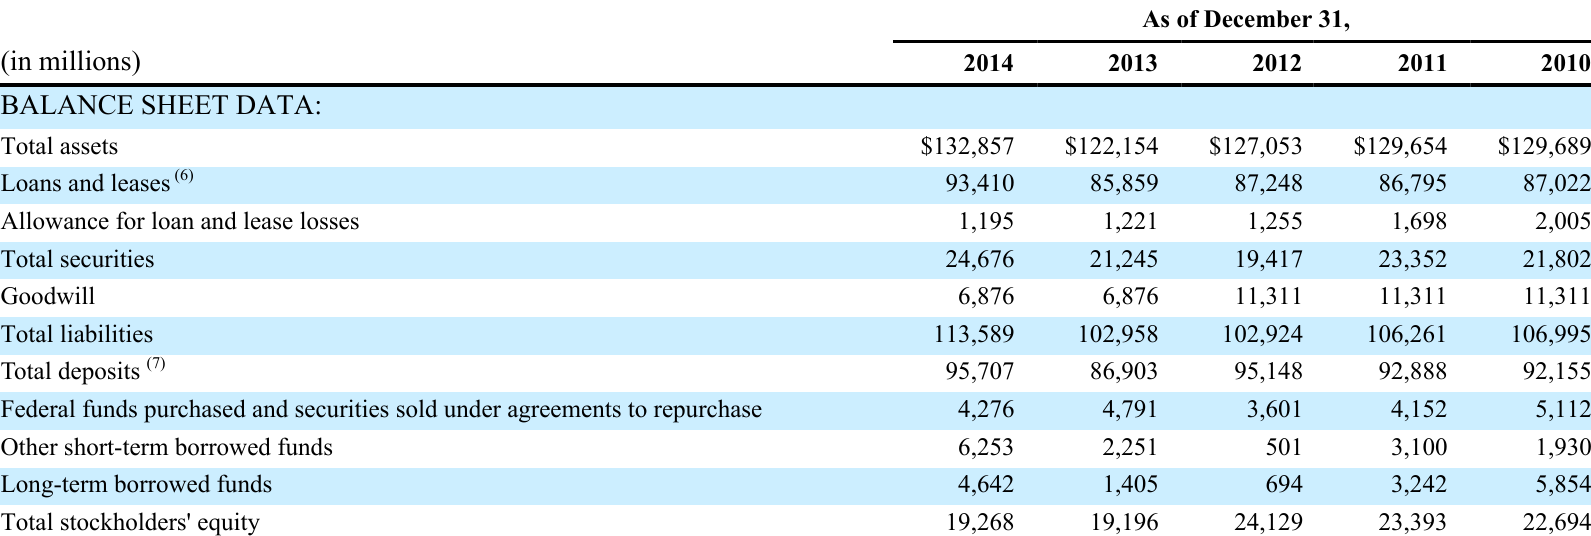


### Predicted Skeleton HTML (raw text, TEDS: 0.0421):
<table> <tr> <td></td> <TD colspan="5"></td> </tr> </table>

### Predicted Merged HTML (Pipeline TEDS: 0.0309):


"As of December 31, (in millions) 2014 2013 2012 2011 2010 BALANCE SHEET DATA: Total assets $132,857 $122,154 $127,035 $129,664 $128,669 Loan and leases (%) 93,410 85,859 87,248 86,795 87.079 Allowance for loan and lease losses 1,195 1,221 1.255 1/088 2,085 Total securities 24,676 21,245 19,417 23,332 21.082 Goodwill 6,876 6,678 11,311 11.311","11:311 Total liabilities 113,589 102,9858 102.924 106,261 106.095 Total deposits () 95,707 86,903 95,148 92,888 92.1588 4,276 4,71 3,601 4.152 5,512 Federal funds purchased and securities sold under agreements to purchase 501 Other short-term borrowed funds 6,253 2,251 3,100 1,190 4,642 1,405 694 3,242 5,858 Long-term borrowing funds 19,268 19,196 24,129 23,939 22,993 Total stockholders' equity"



### Ground Truth HTML:



--- Visualizing Sample 3/3: fintabnet_020787 ---

### Original Image:


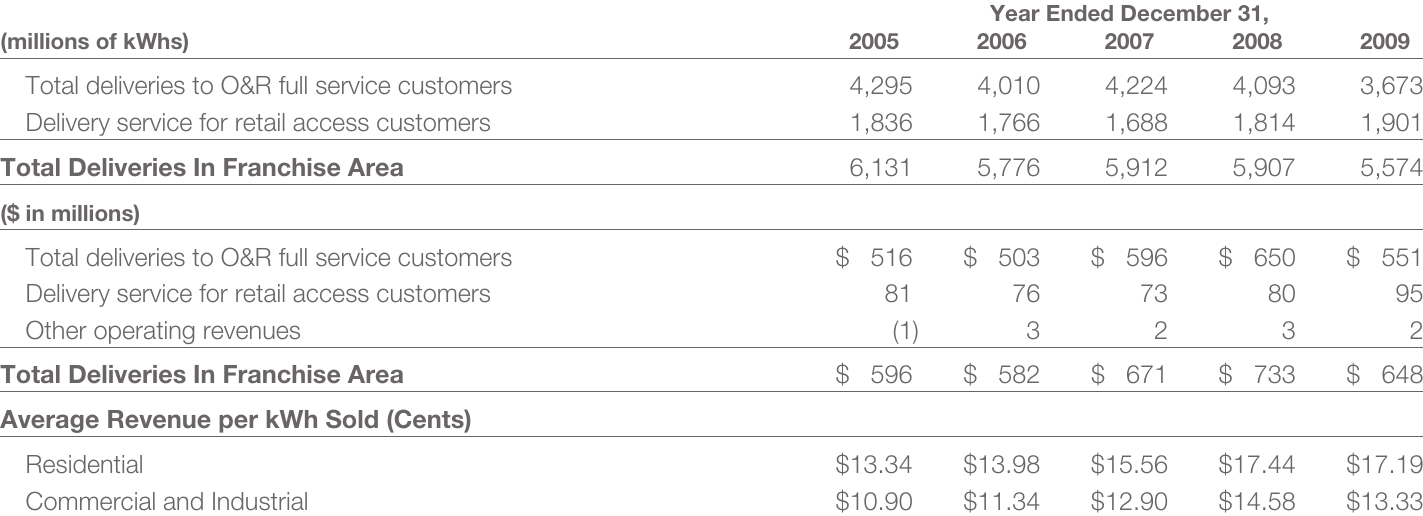


### Predicted Skeleton HTML (raw text, TEDS: 0.0568):
<table> <tr> <td></td> <TD colspan="5"></td> </tr><tr> </table>

### Predicted Merged HTML (Pipeline TEDS: 0.0440):


"Year Ended December 31, 2005 2006 2007 2008 2009 (millions of KWhs) 4,295 4,010 4.224 4_093 3,673 Total deliveries to O8R full service customers 1,836 1,766 1.688 1_814 1-901 Delivery service for retail access customers Total Deliveries In Franchise Area 6,131 5,776 5.912 5_907 5 5,574 (s in millions) $516 $ 503 $ 596 $ 650 $551","Total deliveries in O8r full service customer 81 76 73 80 95 Delivery service to retail access customer 3 2 3 2 Other operating revenues (1) $ 586 $ 582 $ 671 $ 783 $648 Total Deliverives In Franchise area Average Revenue per KWh Sold (Cents) Residential $13.34 $ 13.98 $15.56 $17.44 $ 17.19 $10.90 $11.34 $12.50 $14.58 $13,33 Commercial and Industrial"



### Ground Truth HTML:


In [ ]:
from PIL import Image
from IPython.display import display, HTML
from peft import PeftModel
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoProcessor
import torch
import re
import time
from apted import APTED, Config
from lxml import html as lhtml, etree

# Define global variables used in this cell for model loading and processing
FLORENCE_DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
FLORENCE_MODEL_ID = 'microsoft/Florence-2-base'
SPRINT2_OUT = Path('/content/drive/My Drive/Quarter 3/Computer Vision and DL/Computer_Vision_Team8') / 'outputs' / 'sprint2_1300sample'
PHASE1_CKPT = SPRINT2_OUT / 'checkpoints' / 'phase1_general'

# Load FLORENCE_PROCESSOR and FLORENCE_MODEL if they are not already loaded
# This makes the cell robust to out-of-order execution
if 'FLORENCE_PROCESSOR' not in globals() or 'FLORENCE_MODEL' not in globals():
    print(f'Loading Florence-2-base on {FLORENCE_DEVICE}...')
    FLORENCE_PROCESSOR = AutoProcessor.from_pretrained(
        FLORENCE_MODEL_ID, trust_remote_code=True
    )
    FLORENCE_MODEL = AutoModelForCausalLM.from_pretrained(
        FLORENCE_MODEL_ID,
        trust_remote_code=True,
        torch_dtype=torch.float16,
    ).to(FLORENCE_DEVICE).eval()
    print(f'Florence-2-base ready on {FLORENCE_DEVICE}.')


# --- Function Definitions (copied for self-containment) ---

def clean_html_structure(html_str):
    """
    Strips all text content between <td>/<th> tags — keeps tags and attributes.
    Reduces token length by ~80% so sequences fit under Florence-2's 1024 cap.
    """
    cleaned = re.sub(r'(<td[^>]*>)(.*?)(</td>)', r'\1\3', html_str, flags=re.DOTALL)
    cleaned = re.sub(r'(<th[^>]*>)(.*?)(</th>)', r'\1\3', cleaned, flags=re.DOTALL)
    return ' '.join(cleaned.split())   # collapse whitespace

class TableTree:
    def __init__(self,tag,colspan=1,rowspan=1,content='',children=None):
        self.tag=tag; self.colspan=int(colspan); self.rowspan=int(rowspan); self.content=(content or '').strip(); self.children=children or []

def _parse_el(el):
    return TableTree(el.tag,el.get('colspan',1),el.get('rowspan',1),
                     (el.text or '').strip(),[_parse_el(c) for c in el])

def html_to_tree(html_str):
    try:
        root=lhtml.fromstring(html_str.strip())
        table=root if root.tag=='table' else root.find('.//table')
        return _parse_el(table) if table is not None else TableTree('empty')
    except: return TableTree('error')

def _size(node): return 1+sum(_size(c) for c in node.children)

class _TEDSConfig(Config):
    def rename(self,a,b):
        if a.tag!=b.tag: return 1.0
        if a.colspan!=b.colspan or a.rowspan!=b.rowspan: return 1.0
        if a.content!=b.content: return 0.5
        return 0.0
    def children(self,n): return n.children
    def insert(self,n): return 1.0
    def delete(self,n): return 1.0

def compute_teds(pred_html, true_html):
    if not pred_html or not pred_html.strip(): return 0.0
    pt=html_to_tree(pred_html); tt=html_to_tree(true_html)
    if pt.tag in ('empty','error') or tt.tag in ('empty','error'): return 0.0
    dist=APTED(pt,tt,_TEDSConfig()).compute_edit_distance()
    denom=max(_size(pt),_size(tt))
    return max(0.0,1.0-dist/denom) if denom else 1.0

def run_ocr_with_region(img_path):
    """
    Pass 2: Extract text content using Florence-2's native OCR_WITH_REGION.
    Uses the BASE model (FLORENCE_MODEL) — no fine-tuning needed for OCR.
    Returns list of (text, cx, cy) — normalised centre coordinates [0, image_w/h].
    """
    t0 = time.time()
    try:
        image  = Image.open(img_path).convert('RGB')
        img_w, img_h = image.size
        prompt = '<OCR_WITH_REGION>'
        inputs = FLORENCE_PROCESSOR(text=prompt, images=image, return_tensors='pt')
        inputs = {k: (v.to(FLORENCE_DEVICE, dtype=torch.float16)
                      if v.is_floating_point() else v.to(FLORENCE_DEVICE))
                  for k, v in inputs.items()}

        with torch.no_grad():
            ids = FLORENCE_MODEL.generate(
                input_ids=inputs['input_ids'],
                pixel_values=inputs['pixel_values'],
                max_new_tokens=1280, num_beams=3, early_stopping=True,
            )

        raw    = FLORENCE_PROCESSOR.batch_decode(ids, skip_special_tokens=False)[0]
        parsed = FLORENCE_PROCESSOR.post_process_generation(
            raw, task=prompt, image_size=(img_w, img_h)
        )
        result = parsed.get(prompt, {})
        labels     = result.get('labels', [])
        quad_boxes = result.get('quad_boxes', [])

        ocr_words = []
        for label, quad in zip(labels, quad_boxes):
            if not label.strip(): continue
            # quad = [x1,y1,x2,y2,x3,y3,x4,y4] — four corners
            xs = [quad[i] for i in range(0, len(quad), 2)]
            ys = [quad[i] for i in range(1, len(quad), 2)]
            cx = sum(xs) / len(xs)
            cy = sum(ys) / len(ys)
            clean_label = label.strip().replace('</s>', '').replace('<s>', '').strip()
            if clean_label:
                ocr_words.append((clean_label, cx, cy))

        elapsed = round(time.time()-t0, 2)
        return ocr_words, elapsed

    except Exception as e:
        import traceback; traceback.print_exc()
        print(f'  [OCR] Error on {Path(img_path).name}: {e}')
        return [], round(time.time()-t0, 2)

def merge_skeleton_and_ocr(skeleton_html, ocr_words):
    """
    Pass 3: Fill skeleton <td>/<th> cells with OCR text.
    """
    if not skeleton_html or not skeleton_html.strip():
        return skeleton_html

    try:
        root  = lhtml.fromstring(skeleton_html)
        cells = root.findall('.//td') + root.findall('.//th')

        if not cells or not ocr_words:
            return skeleton_html

        # Sort words: top-to-bottom primary, left-to-right secondary
        sorted_words = sorted(ocr_words, key=lambda w: (w[2], w[1]))

        # Distribute words across cells evenly
        # Simple approach: divide word list into len(cells) equal chunks
        n_cells = len(cells)
        n_words = len(sorted_words)

        if n_words == 0:
            return skeleton_html

        # Words per cell — at least 1 word per cell if possible
        chunk_size = max(1, n_words // n_cells)

        for i, cell in enumerate(cells):
            start = i * chunk_size
            end   = start + chunk_size if i < n_cells - 1 else n_words
            if start < n_words:
                cell_words = [w[0] for w in sorted_words[start:end]]
                cell.text  = ' '.join(cell_words)

        return lhtml.tostring(root, pretty_print=False, encoding='unicode')

    except Exception as e:
        print(f'  [Merge] Error: {e}')
        return skeleton_html

def run_full_pipeline(img_path, true_html, model, processor):
    """
    Complete two-pass pipeline:
      Pass 1: fine-tuned lora_model + <PARSE_TABLE_STRUCTURE> → skeleton HTML
      Pass 2: base FLORENCE_MODEL + <OCR_WITH_REGION>         → OCR word list
      Pass 3: merge_skeleton_and_ocr                          → complete HTML
    Scores merged output against full ground truth TEDS.
    """
    try:
        image  = Image.open(img_path).convert('RGB')
        prompt = '<PARSE_TABLE_STRUCTURE>'
        inputs = processor(text=prompt, images=image, return_tensors='pt')
        inputs = {k: (v.to(FLORENCE_DEVICE, dtype=torch.float16)
                      if v.is_floating_point() else v.to(FLORENCE_DEVICE))
                  for k, v in inputs.items()}

        model.eval()
        with torch.no_grad():
            ids = model.generate(
                input_ids=inputs['input_ids'],
                pixel_values=inputs['pixel_values'],
                max_new_tokens=512, num_beams=2, early_stopping=True,
            )

        raw   = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()
        match = re.search(r'(<table[\s\S]*?</table>)', raw, re.IGNORECASE)
        skeleton = match.group(1) if match else raw

        # Pass 2: OCR content
        ocr_words, _ = run_ocr_with_region(img_path)

        # Pass 3: merge
        merged_html = merge_skeleton_and_ocr(skeleton, ocr_words)

        # Score merged output vs FULL ground truth
        teds = compute_teds(merged_html, true_html)
        return merged_html, skeleton, teds

    except Exception as e:
        print(f'  [Pipeline] Error: {e}')
        return '', '', 0.0

# --- End Function Definitions ---


# Ensure the lora_model is loaded if not already
# This block is for robustness, assuming FORCE_RETRAIN_P1 might be True or False
# and that the notebook might be run out of order.
if 'lora_model' not in locals() or not isinstance(lora_model, PeftModel):
    print("Loading Phase 1 checkpoint...")
    temp_base = AutoModelForCausalLM.from_pretrained(
        FLORENCE_MODEL_ID, trust_remote_code=True, torch_dtype=torch.float16
    ).to(FLORENCE_DEVICE)
    lora_model = PeftModel.from_pretrained(temp_base, str(PHASE1_CKPT))
    lora_model.eval()
    print("Phase 1 model loaded.")

# --- Select a sample to visualize --- (Loop for 3 samples)
num_samples_to_visualize = 3
for i in range(min(num_samples_to_visualize, len(phase1_val))):
    sample_item = phase1_val[i]

    print(f"\n--- Visualizing Sample {i+1}/{num_samples_to_visualize}: {sample_item['img_id']} ---")

    # --- Run the full pipeline ---
    merged_html, skeleton_html, pipeline_teds = run_full_pipeline(
        sample_item['img_path'], sample_item['html'], lora_model, FLORENCE_PROCESSOR
    )
    skel_teds = compute_teds(skeleton_html, clean_html_structure(sample_item['html']))

    # --- Display results ---

    print("\n### Original Image:")
    image = Image.open(sample_item['img_path']).convert('RGB')
    display(image)

    print(f"\n### Predicted Skeleton HTML (raw text, TEDS: {skel_teds:.4f}):")
    print(skeleton_html) # Changed to print raw text

    print(f"\n### Predicted Merged HTML (Pipeline TEDS: {pipeline_teds:.4f}):")
    display(HTML(merged_html))

    print("\n### Ground Truth HTML:")
    display(HTML(sample_item['html']))